In [1]:
import gcmotion as gcm
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 300

<IPython.core.display.Javascript object>

### Part 1: Particle Initialization and obrit calculation

In this cell we can create multiple particles independently. By setting cwp (current working particle), we chose the particle to proceed. That way we can keep all previous particles in memory and switch cwp at any point.

First we set up the Tokamak configuration, and the particle's initial conditions

In [2]:
R, a = 12, 2  # Major/Minor Radius in [m]
q = gcm.qfactor.Unity()#Hypergeometric(R,a)
Bfield = gcm.bfield.LAR(i=0, g=1, B0=5)
Efield = None#gcm.efield.Radial(R, a, q, Ea=75000, minimum=0.9, waist_width=50)

species = "D"
mu = 10e-5
theta0 = 0
psi0 = 0.45  # times psi_wall
zeta0 = np.pi
Pzeta0 = -0.025
t_eval = np.linspace(0, 10000, 10000)  # t0, tf, steps

tokamak     = {"R": R, "a": a, "q": q, "Bfield": Bfield, "Efield":Efield}
init_cond   = {"theta0": theta0, "psi0": psi0, "zeta0": zeta0, "Pzeta0": Pzeta0}

particle1 = gcm.Particle(tokamak, t_eval, init_cond, mu, species)
cwp = particle1

cwp.run()

Constants of motion:
	Particle Energy (normalized):	E = 3.681205e-04
	Particle Energy (eV):		E = 1.332285e+04 eV
	Particle Energy (J):		E = 2.134556e-15 J
	Toroidal Momenta:		Pζ = -0.025

Other Quantities:
	Particle of Species:		"D"
	Orbit Type:			Passing-Lost
	Major Radius:			R = 12 meters
	Minor Radius:			α = 2 meters
	Toroidal Flux at wall:		ψ = 0.0138889
	Time unit:			ω = 2.395245e+08 Hz 
	Energy unit:			E = 2.763076e-08 J 

Solver output: 0: The solver successfully reached the end of the integration interval.
Orbit calculation time: 0.0558s.


### Part 2: Plots

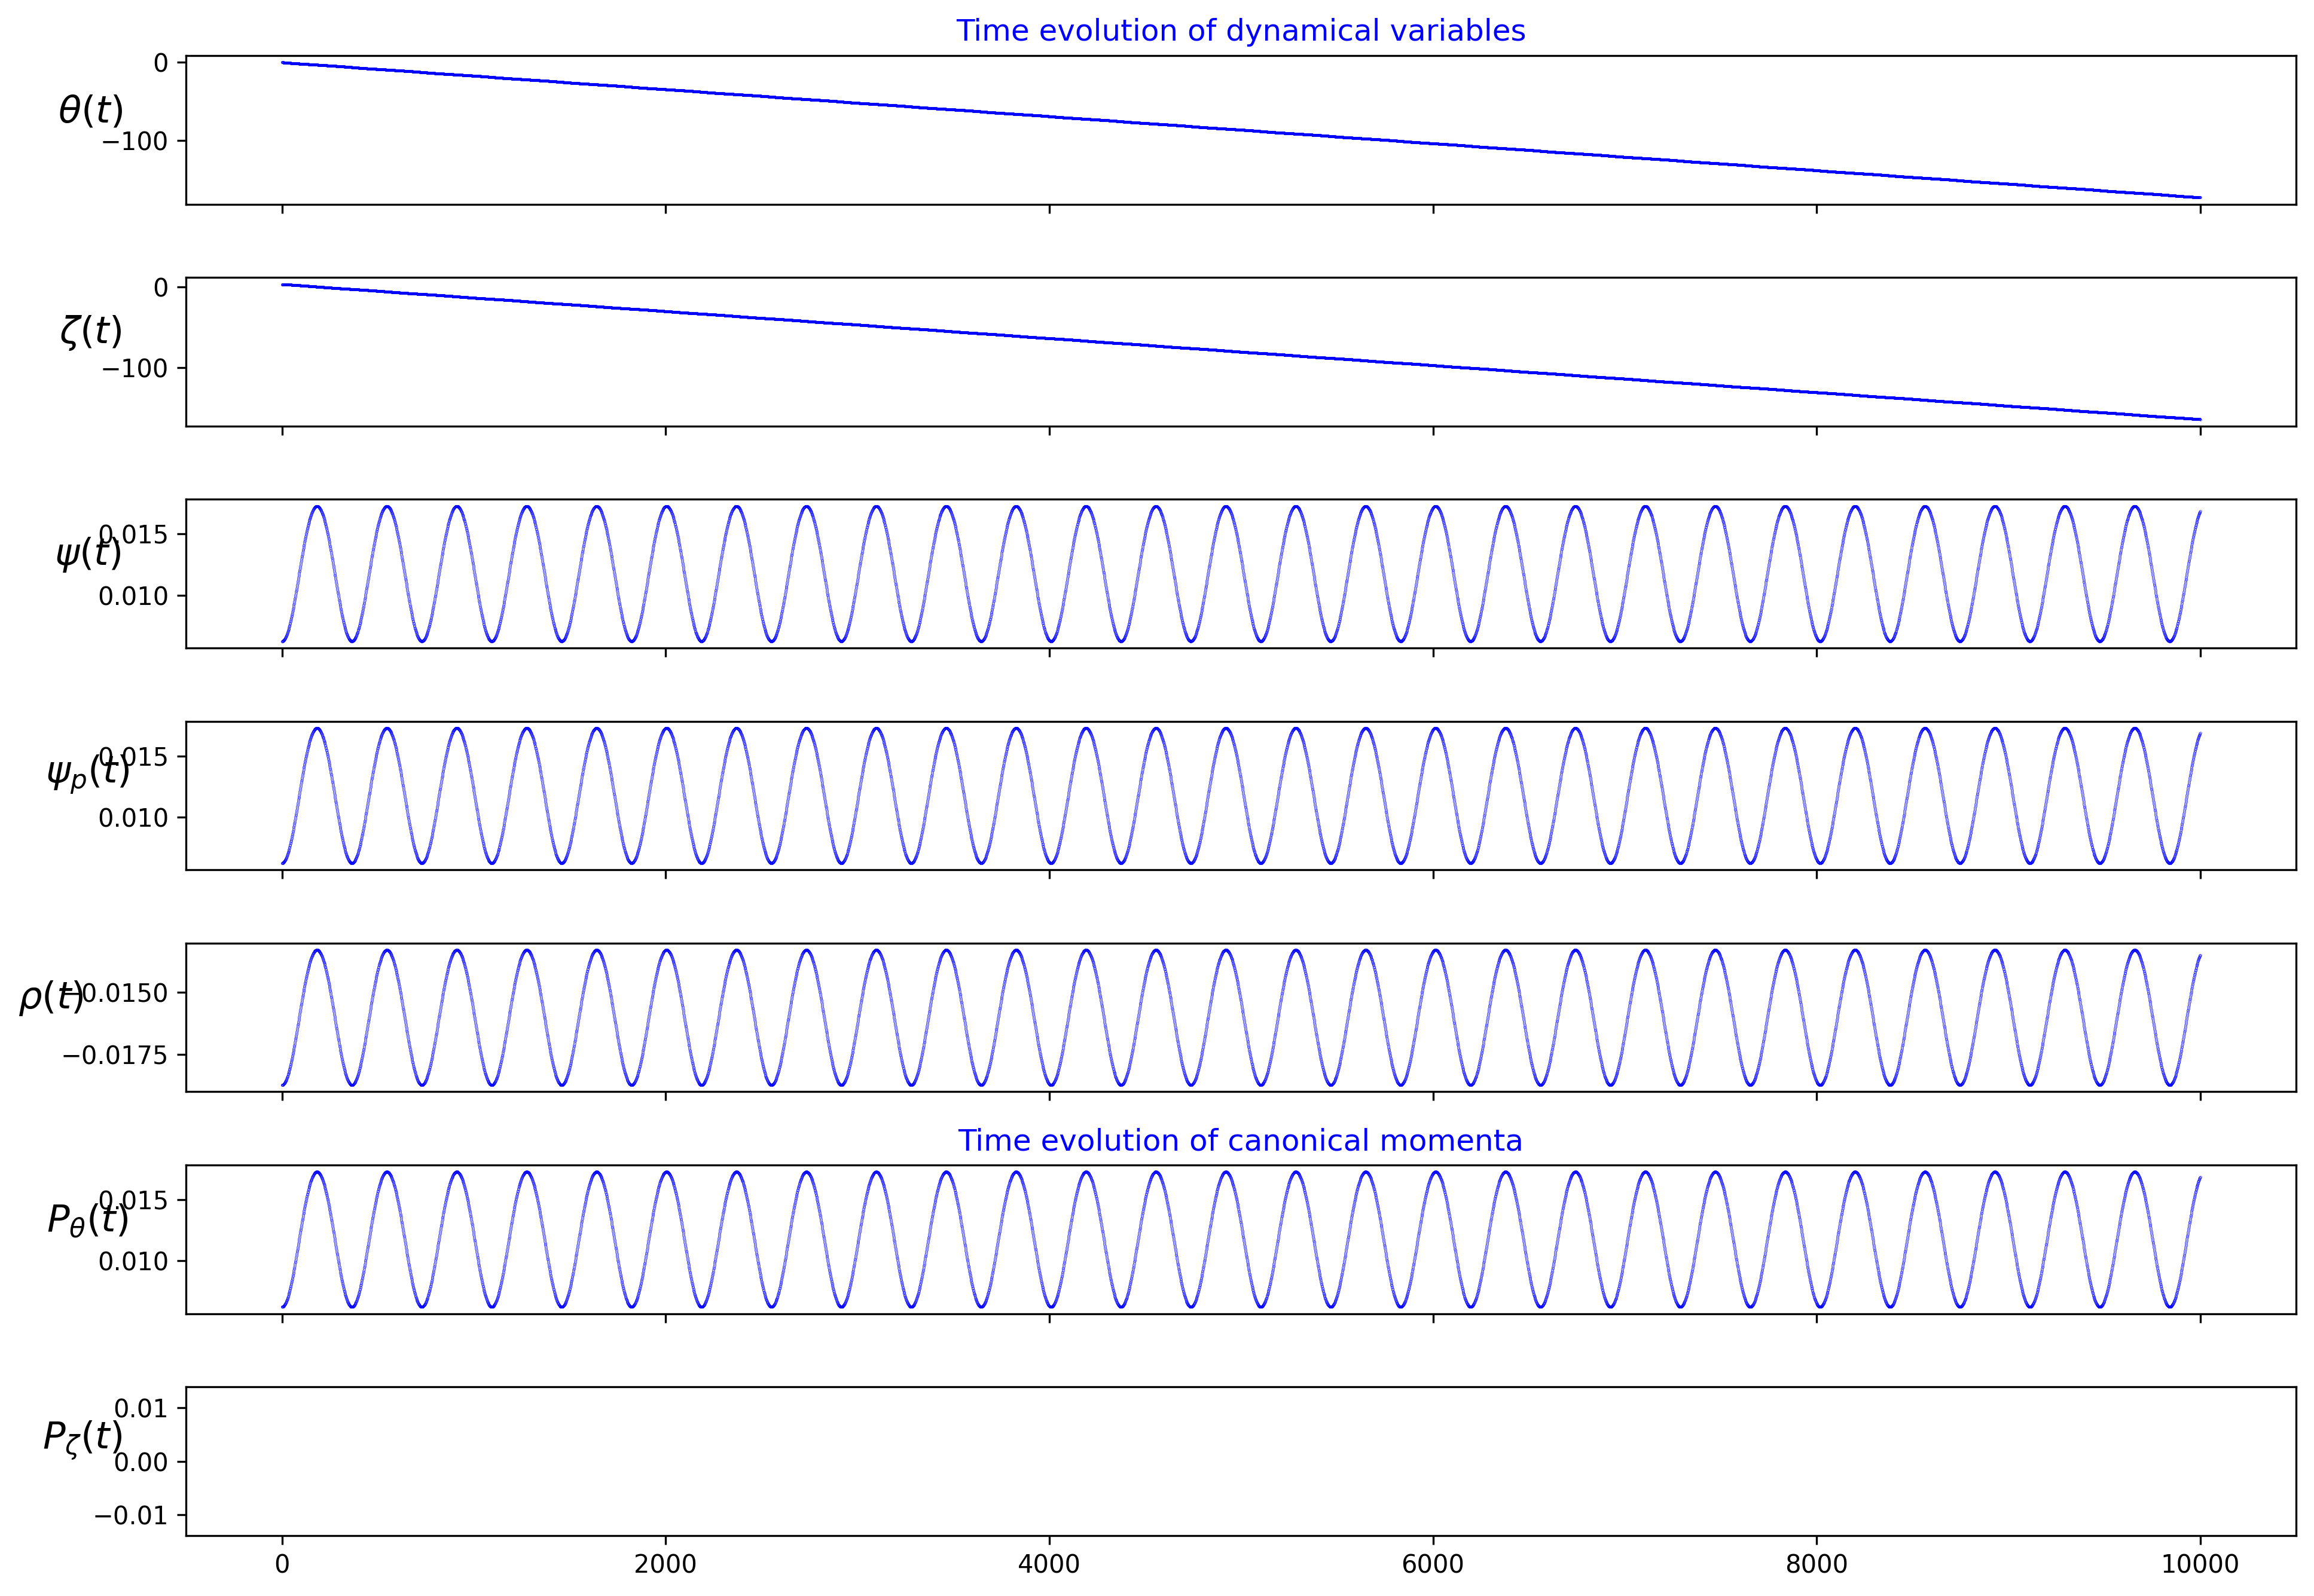

In [3]:
gcm.time_evolution(cwp, percentage=100)

In [4]:
# gcm.tokamak_profile(cwp, zoom = [0, 1.1])

In [5]:
# gcm.drift(cwp, angle = "theta")

In [6]:
# gcm.drifts(cwp)

### Energy Contour Plots

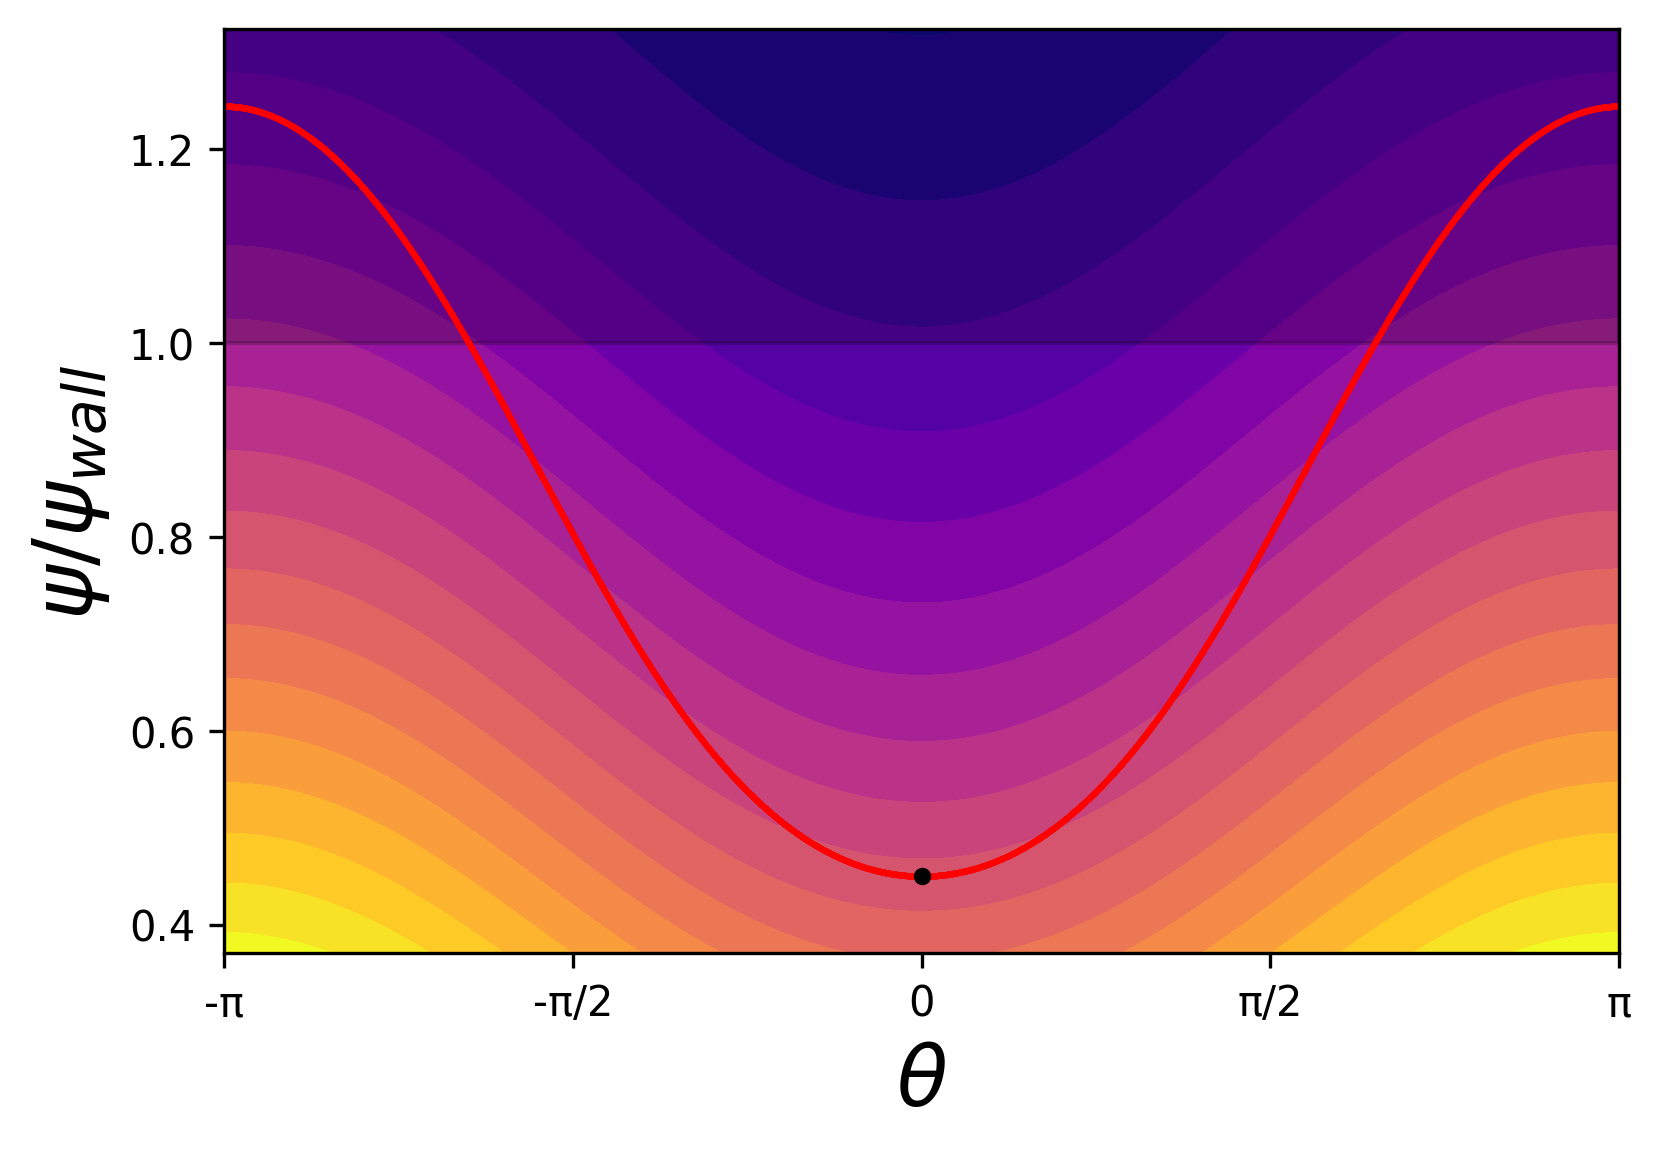

In [7]:
gcm.energy_contour(
    cwp, theta_lim = [-np.pi ,np.pi], psi_lim = "auto", 
    plot_drift=True, contour_Phi = True, units = "keV", levels = 20, 
);

## Orbit types parabolas

As for figuring out if the particle is <ins>L</ins>ost or <ins>C</ins>onfined, we need only to check if its orbit point lies in-between the 2 left parabolas.

In [8]:
# gcm.parabolas(cwp)

## Torus Poincare map and 3d Torus orbits

In [9]:
# gcm.torus2d(cwp)

In [10]:
# gcm.torus3d(cwp)